# Rescue Drone Mission: Modelling and Tracking raft drifting near a rocky shoreline

## Roman Branovets, Skoltech, 2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

### Part I - Constucting the Kalman Filter: From Model to Real-Time Tracking

1. Generating of the true trajectory and velocity of the coordinate

$$
\begin{aligned}
x_i &= x_{i-1} + V_{i-1}T + \frac{a_i T^2}{2}\\
V_i &= V_{i-1} + a_i T
\end{aligned}
$$

In [2]:
#generating_trajectory
steps=200
x_real=np.zeros(steps)
v_real=np.zeros(steps)
t=1
x_real[0]=5
v_real[0]=1
for i in range(1,steps):
    a = np.random.normal(0,0.2)
    x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
    v_real[i]=v_real[i-1]+a*t

2. Generating meausrements of the coordinate

In [3]:
#generating_measurements
z=np.zeros(steps)
for i in range(0,steps):
    z[i]=x_real[i]+np.random.normal(0,20)

Let's vizualite meausrements and real trajectory

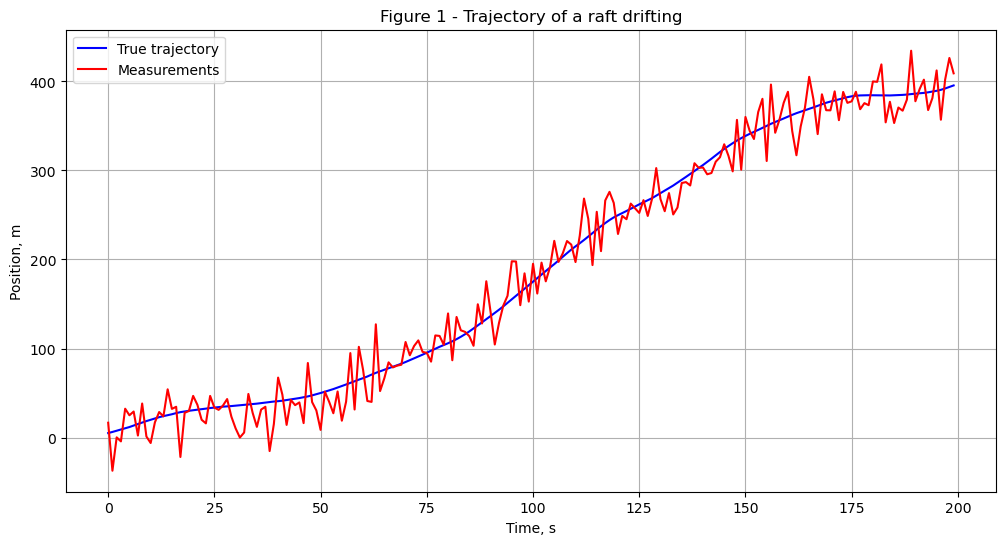

In [4]:
#Plots of real coordinates and measurements
plt.figure(figsize=(12, 6))
plt.plot(x_real, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.title('Figure 1 - Trajectory of a raft drifting')
plt.xlabel('Time, s')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

3. Let's define the parameters of this system

$$
\begin{aligned}
X_i &= \Phi X_{i-1} + Ga_i \\
z_i &= H_i X_i + \eta_i
\end{aligned}
$$

Where

- $X_{i}$ is the state vector
- $\Phi$ is the transition matrix that relates $X_{i}$ and $X_{i-1}$
- $G$ is the input matrix that defines how the random acceleration $a_{i}$ influences the state vector
- $z_{i}$ is the measurement vector, which in this case consists of a measurement of the coordinate $x_{i}$
- $H$ is the observation matrix that relates the measurement vector to the state vector
- $\eta_{i}$ is the measurement noise with the covariance matrix $R_{i}$

In [5]:
#transition matrix
fi=np.matrix([[1,t],[0,1]])
#input matrix
g=np.matrix([[(t**2)/2],[t]])
#observation matrix
h=np.matrix([1,0])
#state vector
X = np.zeros((len(x_real), 2, 1))
for i in range(len(x_real)):
    X[i] = np.array([[x_real[i]], [v_real[i]]])

4. Let's write and configure a Kalman filter

In [6]:
#Initial filtered estimate
X[0]=np.matrix([[2],[0]])
#Filtration error covariance matrix
P=np.zeros((steps, 2, 2))
P[0]=np.matrix([[10000, 0], [0, 10000]])
#Covariance matrix
Q=(g@g.T)*(0.2**2)
R = np.array(20**2)
K = np.zeros((steps, 2, 1))
for i in range(1,len(x_real)):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)/E
    X[i]=X[i]+K[i]*(z[i]-h@X[i])
    P[i]=(np.identity(2)-K[i]@h)@P[i]

5. Let's plot meausrement, real trajectory and filtered estimates

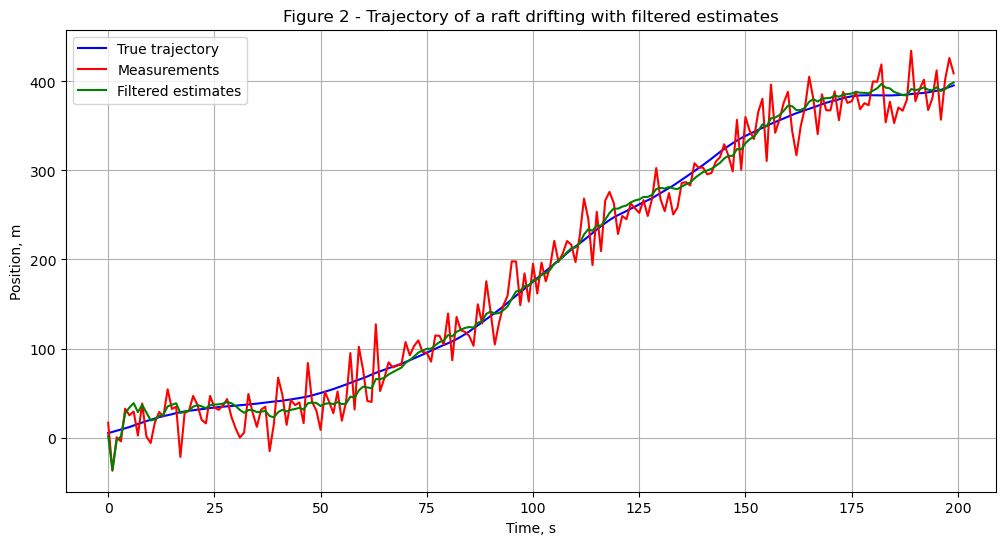

In [7]:
#Plots of real coordinates, measurements and filtered estimates
plt.figure(figsize=(12, 6))
plt.plot(x_real, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.plot(X[:,0,0], color='green',  label='Filtered estimates')
plt.title('Figure 2 - Trajectory of a raft drifting with filtered estimates')
plt.xlabel('Time, s')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

6. Analysis of the filter gain and estimation error in the filtered state vector

Let's plot the filter gain

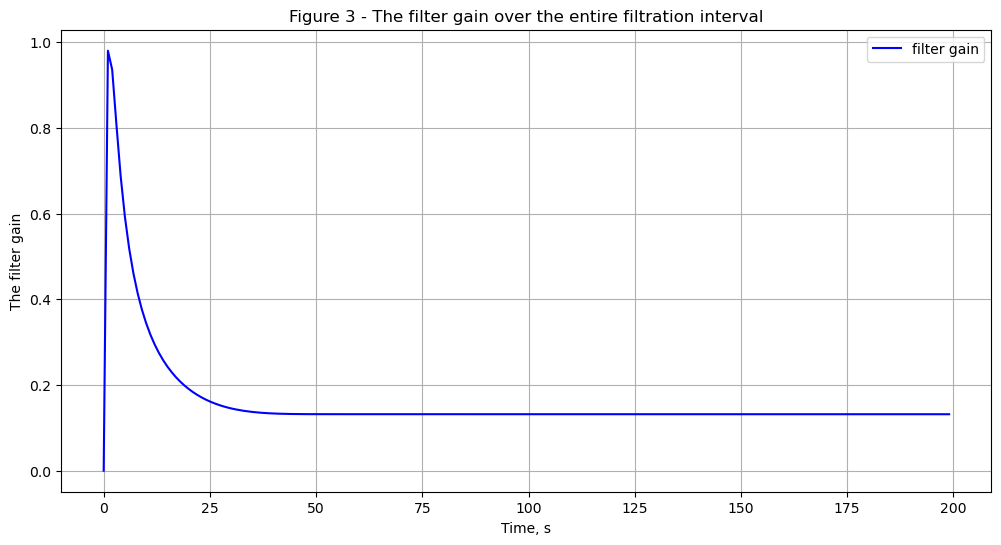

In [8]:
#Plot of the filter gain
plt.figure(figsize=(12, 6))
plt.plot(K[:,0,0], color="blue",  label='filter gain')
plt.title('Figure 3 - The filter gain over the entire filtration interval')
plt.xlabel('Time, s')
plt.ylabel('The filter gain')
plt.legend()
plt.grid()
plt.show()

Let's plot the standard deviation

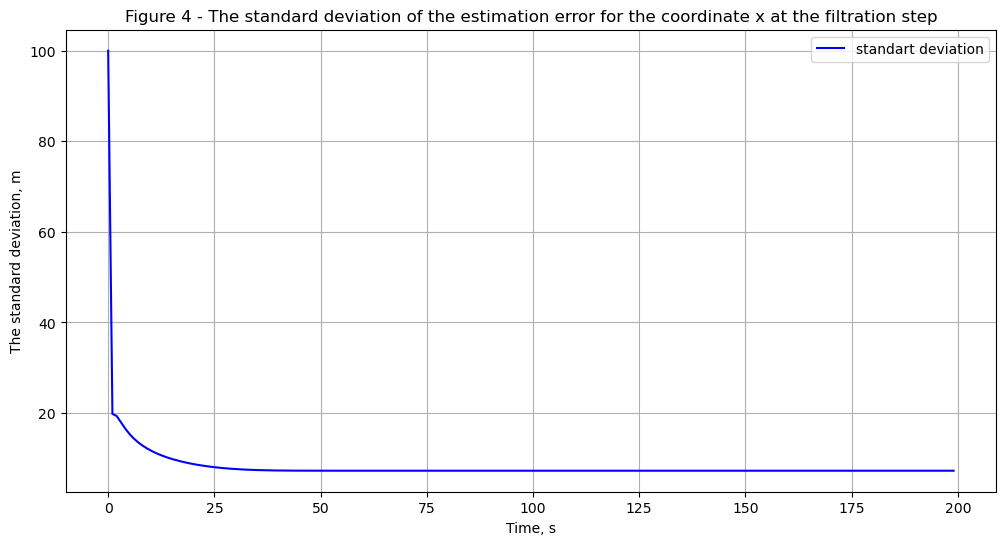

In [9]:
#Plot of the standatd deviation
plt.figure(figsize=(12, 6))
plt.plot(np.sqrt(P[:,0,0]), color="blue",  label='standart deviation')
plt.title('Figure 4 - The standard deviation of the estimation error for the coordinate x at the filtration step')
plt.xlabel('Time, s')
plt.ylabel('The standard deviation, m')
plt.legend()
plt.grid()
plt.show()

As we can see filter gain and standard deviation reach a constant value quickly. It indicates that in
conditions where the trajectory is affected by random noise, we cannot estimate beyond a certain limit of accuracy due to inherent uncertainty.

$𝜎_{𝑥_{𝑖,𝑖}}$ is consistent across each run of the filter. It indicates that the matrices $𝑃_{𝑖,𝑖}$ and $𝑃_{𝑖−1,𝑖}$ remain the same for each run, given fixed statistical characteristics of the state
and measurement noise.

The number of rows in the gain matrix depends on the dimension of state vectors. The number of columns is determined by dimension of the measurement vector. In this task, the size of the filter gain is 2 by 1, since we measure only the position, and the state vector includes 2 values: speed and position

7. Analysis of the filter gain and estimation error in the filtered state vector

In [10]:
#Initial filtered estimate
m=7
X = np.zeros((len(x_real), 2, 1))
for i in range(len(x_real)):
    X[i] = np.array([[x_real[i]], [v_real[i]]])
X[0]=np.matrix([[2],[0]])
X_tuned = np.zeros((len(x_real), 2, 1))
for i in range(len(x_real)):
    X_tuned[i] = np.array([[x_real[i]], [v_real[i]]])
X_tuned[0]=np.matrix([[2],[0]])
#Filtration error covariance matrix
P=np.zeros((steps, 2, 2))
P[0]=np.matrix([[10000, 0], [0, 10000]])
#Covariance matrix
Q=(g@g.T)*(0.2**2)
R = np.array(20**2)
K = np.zeros((steps, 2, 1))
for i in range(1,steps-m+1):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)/E
    X[i]=X[i]+K[i]*(z[i]-h@X[i])
    P[i]=(np.identity(2)-K[i]@h)@P[i]
    X_tuned[i+m-1]=(fi**6)@X[i]

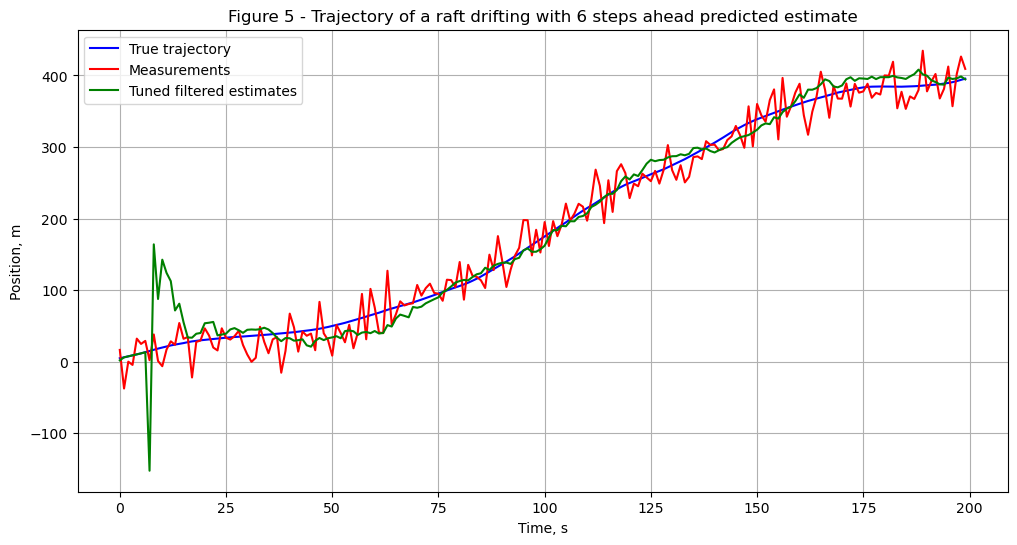

In [11]:
#Plots of real coordinates, measurements and filtered estimates
plt.figure(figsize=(12, 6))
plt.plot(x_real, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.plot(X_tuned[:,0,0], color='green',  label='Tuned filtered estimates')
plt.title('Figure 5 - Trajectory of a raft drifting with 6 steps ahead predicted estimate')
plt.xlabel('Time, s')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

As we can see, the filter performs worse in this case. More sudden jumps occur.

### Part II - Evaluating Accuracy: Optimal Settings vs. Mission Stress Tests

1. Let's run the Kalman filter on 500 different trajectories and see how it works.

Let's calculate error for filtration

In [12]:
#calculate error for filtration
M=500
error=np.zeros((M,steps))
fin_err=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z=np.zeros(steps)
    for i in range(0,steps):
        z[i]=x_real[i]+np.random.normal(0,20)
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matri
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[10000, 0], [0, 10000]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
    for k in range(2,steps):
        error[o,k]=(x_real[k]-X[k,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_err[i]=fin_err[i]+((1/(M-1))*error[j,i])
    fin_err[i]=sqrt(fin_err[i])

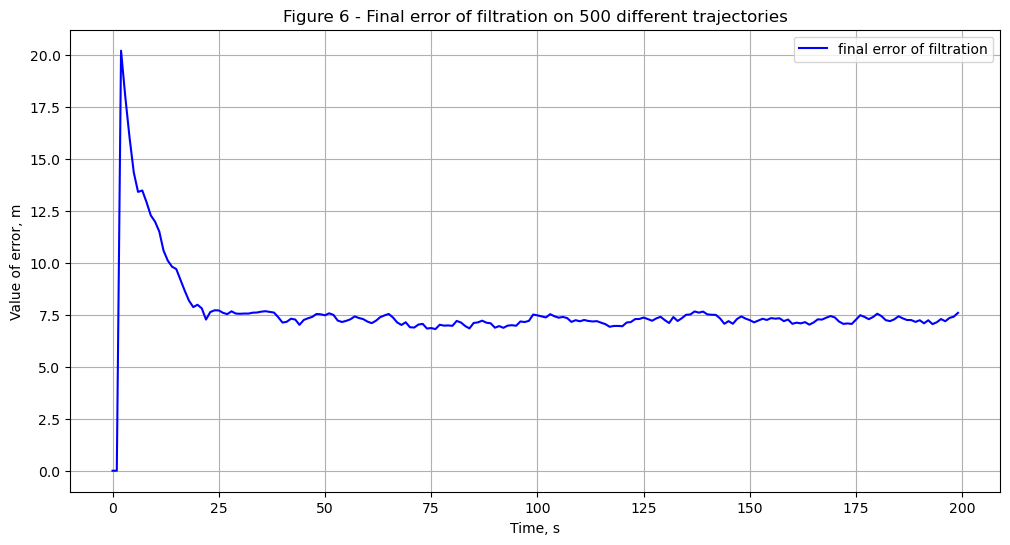

In [13]:
#Plot of the final error
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue",  label='final error of filtration')
plt.title('Figure 6 - Final error of filtration on 500 different trajectories')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

Let's calculate error for prediction

In [14]:
#calculate error for prediction
M=500
error=np.zeros((M,steps))
fin_err=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z=np.zeros(steps)
    for i in range(0,steps):
        z[i]=x_real[i]+np.random.normal(0,20)
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matrix
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[10000, 0], [0, 10000]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        if i>1:
            error[o,i]=(x_real[i]-X[i,0,0])**2
        P[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
for i in range(steps):
    for j in range(M):
        fin_err[i]=fin_err[i]+((1/(M-1))*error[j,i])
    fin_err[i]=sqrt(fin_err[i])

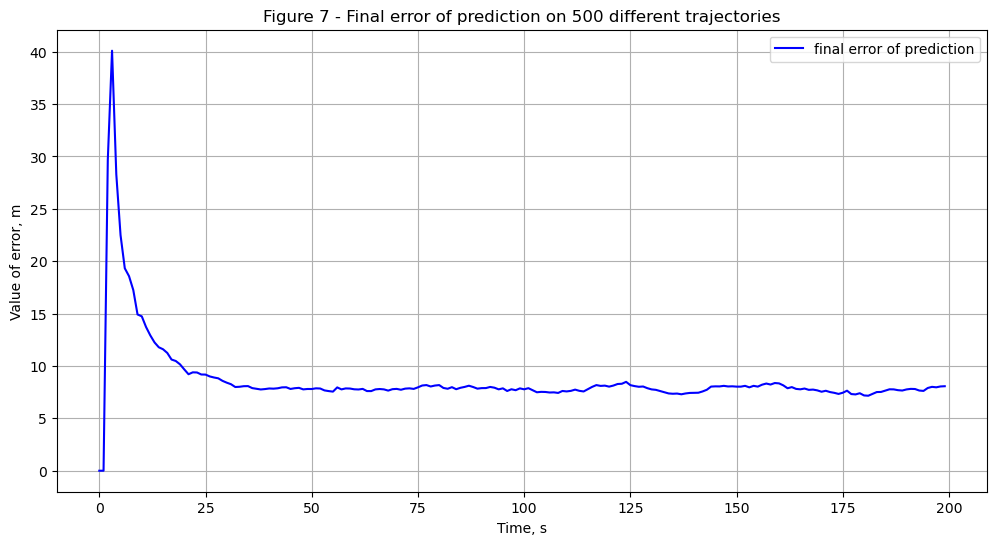

In [15]:
#Plot of the final error
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue",  label='final error of prediction')
plt.title('Figure 7 - Final error of prediction on 500 different trajectories')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.grid()
plt.legend()
plt.show()

Let's calculate error for prediction on 7 steps

In [16]:
#calculate error for prediction on 7 steps
M=500
error=np.zeros((M,steps))
fin_err=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z=np.zeros(steps)
    for i in range(0,steps):
        z[i]=x_real[i]+np.random.normal(0,20)
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matrix
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    m=7
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    X[0]=np.matrix([[2],[0]])
    X_tuned = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X_tuned[i] = np.array([[x_real[i]], [v_real[i]]])
    X_tuned[0]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[10000, 0], [0, 10000]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,steps-m+1):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
        X_tuned[i+m-1]=(fi**6)@X[i]
    for k in range(2,steps):
        error[o,k]=(x_real[k]-X_tuned[k,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_err[i]=fin_err[i]+((1/(M-1))*error[j,i])
    fin_err[i]=sqrt(fin_err[i])

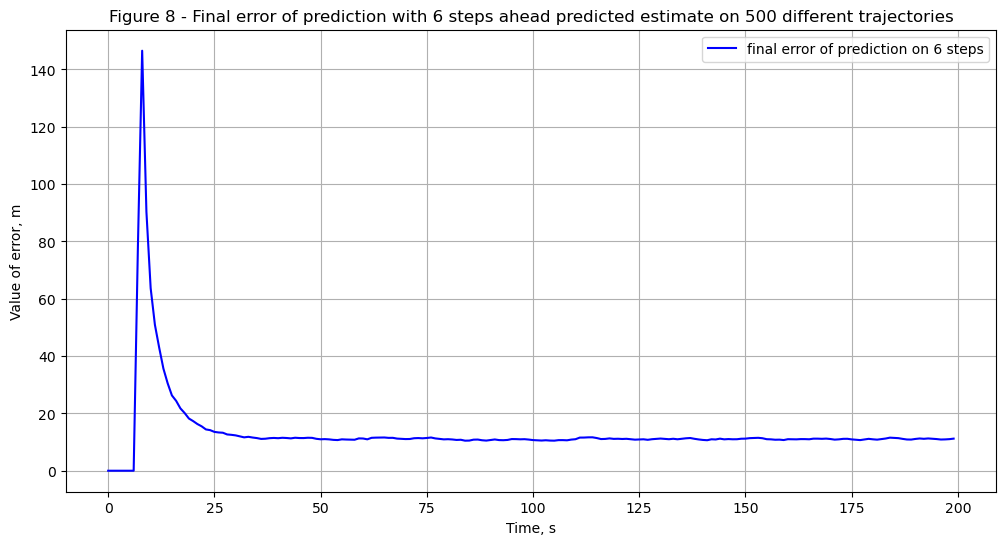

In [17]:
#Plot of the final error
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue", label='final error of prediction on 6 steps')
plt.title('Figure 8 - Final error of prediction with 6 steps ahead predicted estimate on 500 different trajectories')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

As we can see at step 25, the mean square error stops growing and remains constant.

2. In steady-state operation, the Kalman filter's root-mean-square error was 7.5, which is 12.5 less than the specified value during generation. The filter reduced the measurement noise, while the noise of the system itself remained constant (random accelerations). For predicted estimate $x_{i+1, i}$  the Kalman filter's root-mean-square error was 8, which is 12 less than the specified value during generation. For predicted estimate $x_{i+m-1, i}$  the Kalman filter's root-mean-square error was 11, which is 9 less than the specified value during generation. This suggests that the filter is operating effectively. 

3. Let's run the filter again but with a different initial filtration error
covariance matrix

In [18]:
#calculate error for filtration
M=500
error=np.zeros((M,steps))
fin_err=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z=np.zeros(steps)
    for i in range(0,steps):
        z[i]=x_real[i]+np.random.normal(0,20)
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matrix
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[100, 0], [0, 100]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
    for k in range(2,steps):
        error[o,k]=(x_real[k]-X[k,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_err[i]=fin_err[i]+((1/(M-1))*error[j,i])
    fin_err[i]=sqrt(fin_err[i])

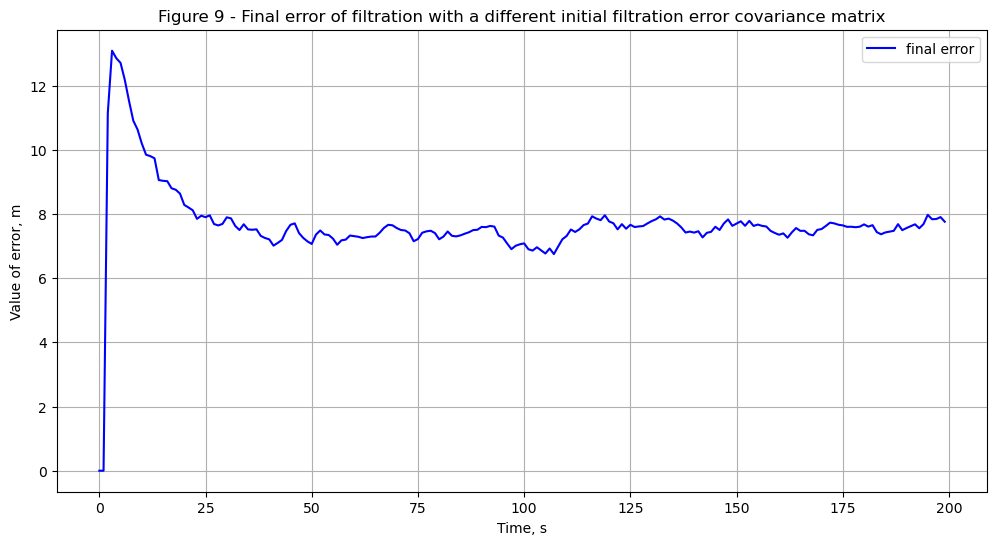

In [19]:
#Plot of the final error
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue", label='final error')
plt.title('Figure 9 - Final error of filtration with a different initial filtration error covariance matrix')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

From the comparison of the graphs, we can conclude that at the initial moment of time value of error is smaller, but at the 25th step  the choice of initial conditions
no longer significantly affect the estimation outcomes

4. Let's compare the actual and calculated variances

1) For filtration values

In [20]:
 #calculate error for filtration
M=500
error=np.zeros((M,steps))
fin_err=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z=np.zeros(steps)
    for i in range(0,steps):
        z[i]=x_real[i]+np.random.normal(0,20)
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matri
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[100, 0], [0, 100]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
    for k in range(2,steps):
        error[o,k]=(x_real[k]-X[k,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_err[i]=fin_err[i]+((1/(M-1))*error[j,i])
    fin_err[i]=sqrt(fin_err[i])

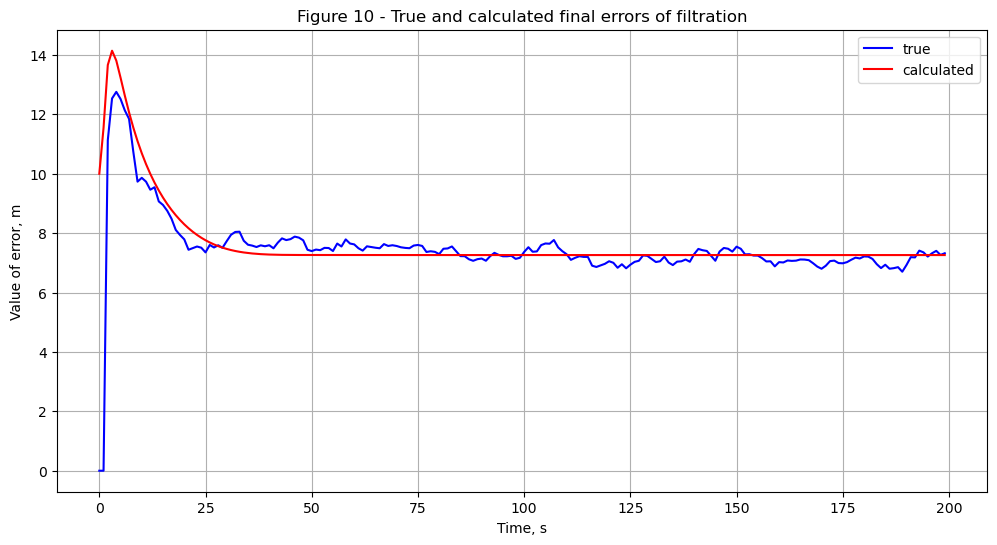

In [21]:
#Plot of the true and calculated errors of filtration
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue",  label='true')
plt.plot(np.sqrt(P[:,0,0]), color="red",  label='calculated')
plt.title('Figure 10 - True and calculated final errors of filtration')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

2. For predicted values

In [22]:
#calculate error for prediction
M=500
error=np.zeros((M,steps))
fin_err=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z=np.zeros(steps)
    for i in range(0,steps):
        z[i]=x_real[i]+np.random.normal(0,20)
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matri
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[100, 0], [0, 100]])
    P_viz=np.zeros((steps, 2, 2))
    P_viz[0]=np.matrix([[100, 0], [0, 100]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        if i>1:
            error[o,i]=(x_real[i]-X[i,0,0])**2
        P[i]=(fi@P[i-1]@fi.T)+Q
        P_viz[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
for i in range(steps):
    for j in range(M):
        fin_err[i]=fin_err[i]+((1/(M-1))*error[j,i])
    fin_err[i]=sqrt(fin_err[i])

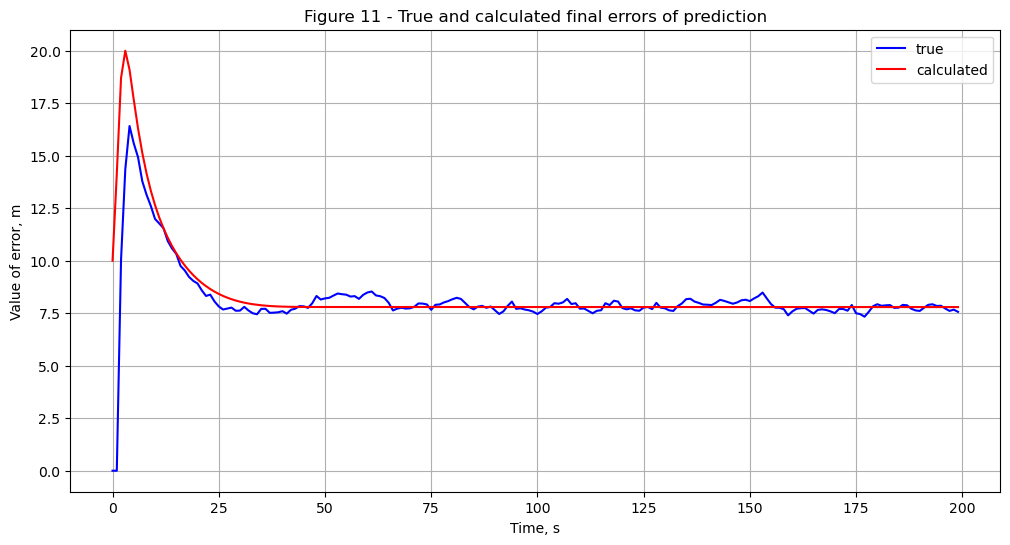

In [23]:
#Plot of the final error and matrix P
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue",  label='true')
plt.plot(np.sqrt(P_viz[:,0,0]), color="red",  label='calculated')
plt.title('Figure 11 - True and calculated final errors of prediction')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

From the comparison, we can see that the calculated and actual errors correspond. This is very useful for understanding the moment of filter calculation when we have achieved the required accuracy. And they converge because the matrix element is the measurement error.

5. Let's run a deterministic filter

In [24]:
 #calculate error for filtration
M=500
error=np.zeros((M,steps))
fin_err=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((np.random.normal(0,0.0)*(t**2))/2)
        v_real[i]=v_real[i-1]+np.random.normal(0,0.0)*t
    #generating_measurements
    z=np.zeros(steps)
    for i in range(0,steps):
        z[i]=x_real[i]+np.random.normal(0,20)
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matrix
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[100, 0], [0, 100]])
    #Covariance matrix
    Q=(g@g.T)*(0.0**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
    for k in range(2,steps):
        error[o,k]=(x_real[k]-X[k,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_err[i]=fin_err[i]+((1/(M-1))*error[j,i])
    fin_err[i]=sqrt(fin_err[i])

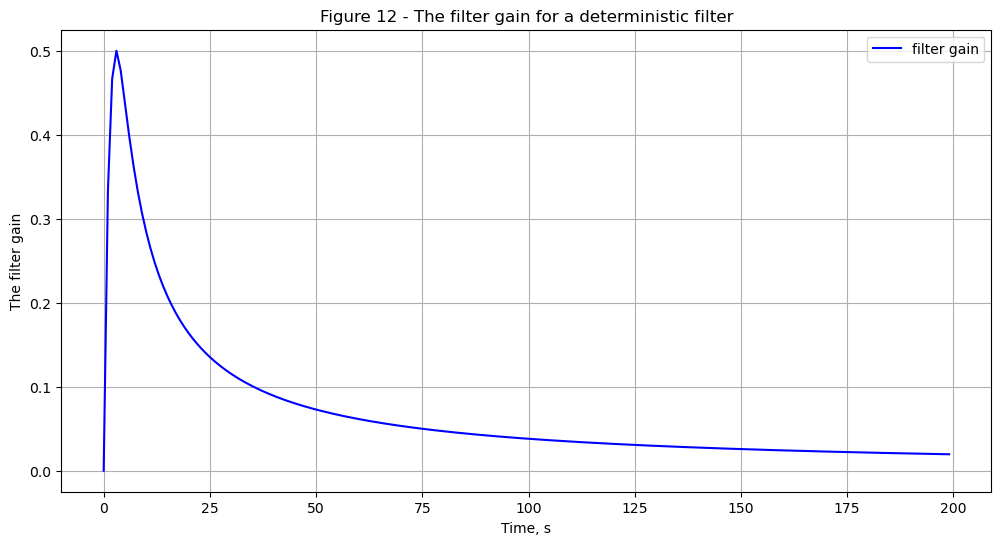

In [25]:
#Plot of the filter gain
plt.figure(figsize=(12, 6))
plt.plot(K[:,0,0], color="blue",  label='filter gain')
plt.title('Figure 12 - The filter gain for a deterministic filter')
plt.xlabel('Time, s')
plt.ylabel('The filter gain')
plt.grid()
plt.legend()
plt.show()

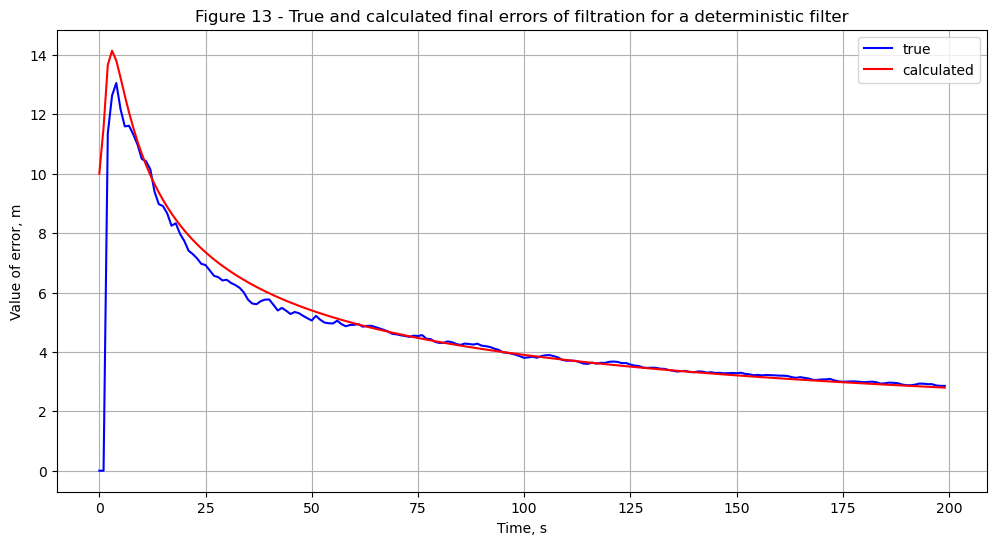

In [26]:
#Plot of the final error and matrix P
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue",  label='true')
plt.plot(np.sqrt(P[:,0,0]), color="red",  label='calculated')
plt.title('Figure 13 - True and calculated final errors of filtration for a deterministic filter')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

This indicates that, in the absence of random disturbances, the estimation error approaches
zero, causing the filter to effectively switch off from measurements, resulting in minimal or
zero adjustments to the estimates from new measurements.

6. Let's stochastic model with a filter designed for a deterministic model

Let's look at the error of the filtered and predicted value

In [27]:
#calculate error for prediction on 6 steps
M=500
error=np.zeros((M,steps))
errorm=np.zeros((M,steps))
fin_err=np.zeros(steps)
fin_errm=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z=np.zeros(steps)
    for i in range(0,steps):
        z[i]=x_real[i]+np.random.normal(0,20)
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matrix
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    m=7
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    X[0]=np.matrix([[2],[0]])
    X_tuned = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X_tuned[i] = np.array([[x_real[i]], [v_real[i]]])
    X_tuned[0]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[100, 0], [0, 100]])
    #Covariance matrix
    Q=np.matrix([[0,0],[0,0]])
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,steps):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
        if i <steps-m+1:
            X_tuned[i+m-1]=(fi**6)@X[i]
    for k in range(2,steps):
        errorm[o,k]=(x_real[k]-X_tuned[k,0,0])**2
        error[o,k]=(x_real[k]-X[k,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_err[i]=fin_err[i]+((1/(M-1))*error[j,i])
        fin_errm[i]=fin_errm[i]+((1/(M-1))*errorm[j,i])
    fin_err[i]=sqrt(fin_err[i])
    fin_errm[i]=sqrt(fin_errm[i])

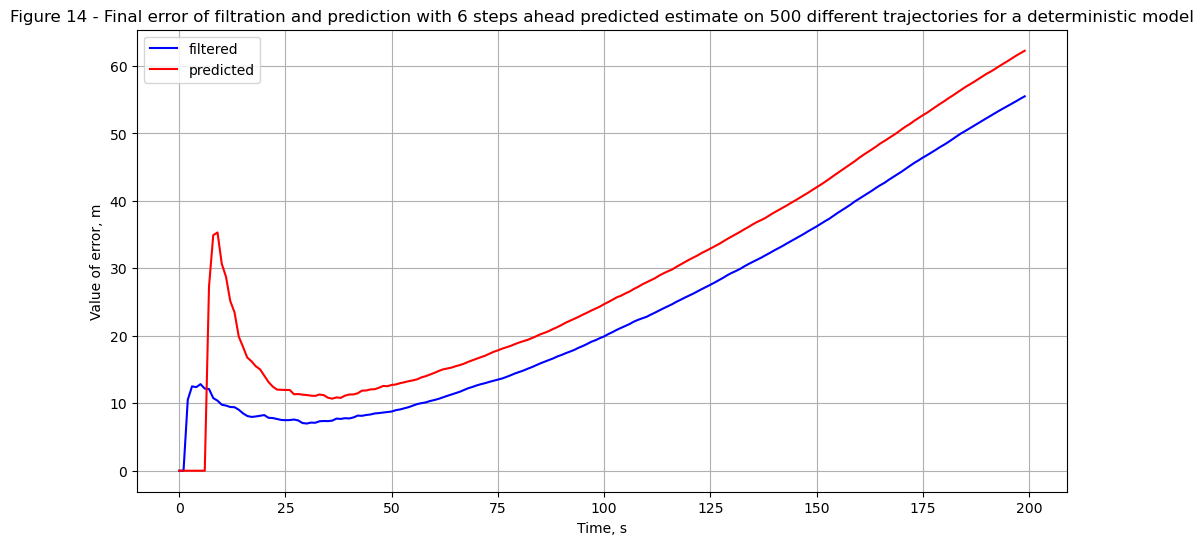

In [28]:
#Plot of the final error
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue", label='filtered')
plt.plot(fin_errm, color="red", label='predicted')
plt.title('Figure 14 - Final error of filtration and prediction with 6 steps ahead predicted estimate on 500 different trajectories for a deterministic model')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.grid()
plt.legend()
plt.show()

As we can see, in both cases, both when using the prediction and when using the correction up to the 25th step, the error falls, and then sharply increases, the value of final error for the predicted value is greater tham final error of filtered value. With each new step, the filter decreases its accuracy. In this case, it will lead to incorrect results. Therefore, it is very important to accurately tune the
Kalman filter to achieve effective solutions

Let's compare this to how the prediction would work without taking noise into account in the covariance matrix.

In [29]:
#calculate error for filtration
M=500
error=np.zeros((M,steps))
fin_err=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z=np.zeros(steps)
    for i in range(0,steps):
        z[i]=x_real[i]+np.random.normal(0,20)
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matrix
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[100, 0], [0, 100]])
    #Covariance matrix
    Q=np.matrix([[0,0],[0,0]])
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
    for k in range(2,steps):
        error[o,k]=(x_real[k]-X[k,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_err[i]=fin_err[i]+((1/(M-1))*error[j,i])
    fin_err[i]=sqrt(fin_err[i])

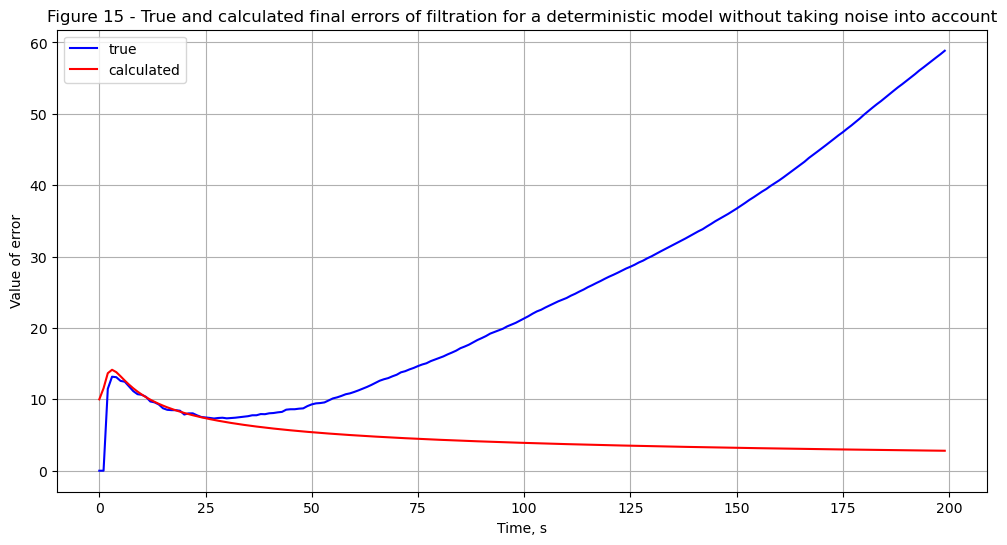

In [30]:
#Plot of the final error and matrix P
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue",  label='true')
plt.plot(np.sqrt(P[:,0,0]), color="red",  label='calculated')
plt.title('Figure 15 - True and calculated final errors of filtration for a deterministic model without taking noise into account')
plt.xlabel('Time, s')
plt.ylabel('Value of error')
plt.legend()
plt.grid()
plt.show()

As we can see, if we neglect the state noise covariance matrix, the Kalman filter algorithm diverges at a certain point because the state error of the Kalman filter does not correspond to the actual divergence error.

7. Analysis of the relationship between state and measurement noise

Let's study how the variance ratio affects the Kalman filter gain using two different values of the state noise variance

In [31]:
#state noise variance=1
#generating_trajectory
steps=200
x_real=np.zeros(steps)
v_real=np.zeros(steps)
t=1
x_real[0]=5
v_real[0]=1
for i in range(1,steps):
    a = np.random.normal(0,1.0)
    x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
    v_real[i]=v_real[i-1]+a*t
#generating_measurements
z=np.zeros(steps)
for i in range(0,steps):
    z[i]=x_real[i]+np.random.normal(0,20)
#transition matrix
fi=np.matrix([[1,t],[0,1]])
#input matrix
g=np.matrix([[(t**2)/2],[t]])
#observation matrix
h=np.matrix([1,0])
#state vector
X = np.zeros((len(x_real), 2, 1))
for i in range(len(x_real)):
    X[i] = np.array([[x_real[i]], [v_real[i]]])
#Initial filtered estimate
X[0]=np.matrix([[2],[0]])
#Filtration error covariance matrix
P=np.zeros((steps, 2, 2))
P[0]=np.matrix([[100, 0], [0, 100]])
#Covariance matrix
Q=(g@g.T)*(1.0**2)
R = np.array(20**2)
K1 = np.zeros((steps, 2, 1))
for i in range(1,len(x_real)):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h@P[i]@h.T + R
    K1[i]=(P[i]@h.T)/E
    X[i]=X[i]+K1[i]*(z[i]-h@X[i])
    P[i]=(np.identity(2)-K1[i]@h)@P[i]
print(f'Ratio is equal {1.0/20.0}')

Ratio is equal 0.05


In [32]:
#state noise variance=0.2
#generating_trajectory
steps=200
x_real=np.zeros(steps)
v_real=np.zeros(steps)
t=1
x_real[0]=5
v_real[0]=1
for i in range(1,steps):
    a = np.random.normal(0,0.2)
    x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
    v_real[i]=v_real[i-1]+a*t
#generating_measurements
z=np.zeros(steps)
for i in range(0,steps):
    z[i]=x_real[i]+np.random.normal(0,20)
#transition matrix
fi=np.matrix([[1,t],[0,1]])
#input matrix
g=np.matrix([[(t**2)/2],[t]])
#observation matrix
h=np.matrix([1,0])
#state vector
X = np.zeros((len(x_real), 2, 1))
for i in range(len(x_real)):
    X[i] = np.array([[x_real[i]], [v_real[i]]])
#Initial filtered estimate
X[0]=np.matrix([[2],[0]])
#Filtration error covariance matrix
P=np.zeros((steps, 2, 2))
P[0]=np.matrix([[100, 0], [0, 100]])
#Covariance matrix
Q=(g@g.T)*(0.2**2)
R = np.array(20**2)
K2 = np.zeros((steps, 2, 1))
for i in range(1,len(x_real)):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h@P[i]@h.T + R
    K2[i]=(P[i]@h.T)/E
    X[i]=X[i]+K2[i]*(z[i]-h@X[i])
    P[i]=(np.identity(2)-K2[i]@h)@P[i]
print(f'Ratio is equal {0.2/20.0}')

Ratio is equal 0.01


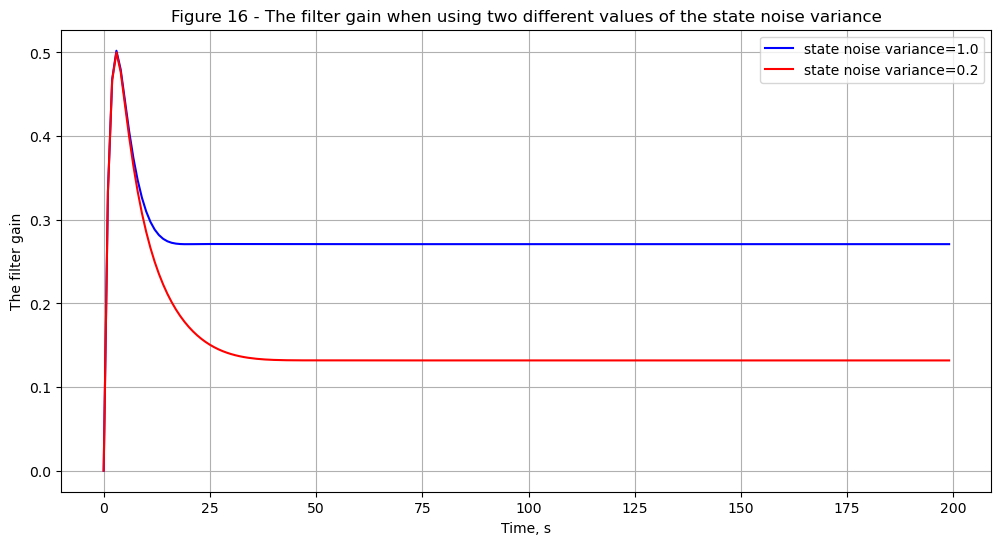

In [33]:
#Plot of the filter gains
plt.figure(figsize=(12, 6))
plt.plot(K1[:,0,0], color="blue",  label='state noise variance=1.0')
plt.plot(K2[:,0,0], color="red",  label='state noise variance=0.2')
plt.title('Figure 16 - The filter gain when using two different values of the state noise variance')
plt.xlabel('Time, s')
plt.ylabel('The filter gain')
plt.legend()
plt.grid()
plt.show()

As we can see, the higher the ratio, the greater the gain. This is as if the filter is more directly on the meter. The filter has to rely more on measurements due to the higher uncertainty of the motion model.

8. Let's explore the effects of filter gain

First, let's set up our model parameters and plot a graph to find out the steady-state value.

In [34]:
#state noise variance=0.2
#generating_trajectory
steps=200
x_real=np.zeros(steps)
v_real=np.zeros(steps)
t=1
x_real[0]=100
v_real[0]=5
for i in range(1,steps):
    a = np.random.normal(0,0.2)
    x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
    v_real[i]=v_real[i-1]+a*t
#generating_measurements
z=np.zeros(steps)
for i in range(0,steps):
    z[i]=x_real[i]+np.random.normal(0,20)
#transition matrix
fi=np.matrix([[1,t],[0,1]])
#input matrix
g=np.matrix([[(t**2)/2],[t]])
#observation matrix
h=np.matrix([1,0])
#state vector
X = np.zeros((len(x_real), 2, 1))
for i in range(len(x_real)):
    X[i] = np.array([[x_real[i]], [v_real[i]]])
#Initial filtered estimate
X[0]=np.matrix([[2],[0]])
#Filtration error covariance matrix
P=np.zeros((steps, 2, 2))
P[0]=np.matrix([[100, 0], [0, 100]])
#Covariance matrix
Q=(g@g.T)*(0.2**2)
R = np.array(20**2)
K = np.zeros((steps, 2, 1))
for i in range(1,len(x_real)):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)/E
    X[i]=X[i]+K[i]*(z[i]-h@X[i])
    P[i]=(np.identity(2)-K[i]@h)@P[i]

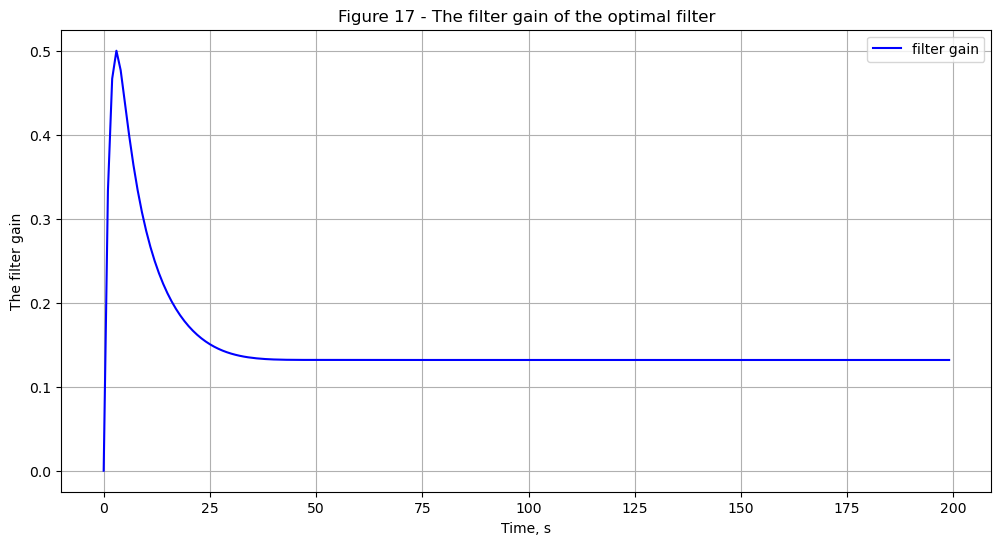

In [35]:
#Plot of the filter gain
plt.figure(figsize=(12, 6))
plt.plot(K[:,0,0], color="blue",  label='filter gain')
plt.title('Figure 17 - The filter gain of the optimal filter')
plt.xlabel('Time, s')
plt.ylabel('The filter gain')
plt.legend()
plt.grid()
plt.show()


As we can see, optimal filter gain is 0.13185

In [36]:
 #calculate error for filtration with optimal K
M=500
error=np.zeros((M,steps))
fin_err=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=100
    v_real[0]=5
    for i in range(1,steps):
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((np.random.normal(0,0.2)*(t**2))/2)
        v_real[i]=v_real[i-1]+np.random.normal(0,0.2)*t
    #generating_measurements
    z=np.zeros(steps)
    for i in range(0,steps):
        z[i]=x_real[i]+np.random.normal(0,20)
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matrix
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[100],[5]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[100, 0], [0, 100]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        K[i,0]=0.13185
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
    for k in range(2,steps):
        error[o,k]=(x_real[k]-X[k,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_err[i]=fin_err[i]+((1/(M-1))*error[j,i])
    fin_err[i]=sqrt(fin_err[i])

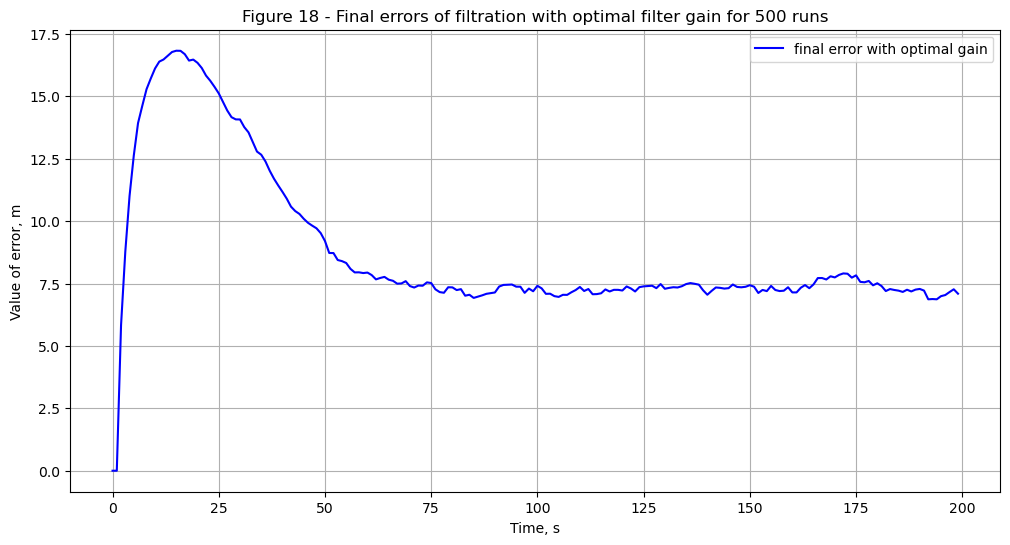

In [37]:
#Plot of the final error with optimal K
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue",  label='final error with optimal gain')
plt.title('Figure 18 - Final errors of filtration with optimal filter gain for 500 runs')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

In [38]:
 #calculate error for filtration with underestimated K
M=500
error=np.zeros((M,steps))
fin_err=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=100
    v_real[0]=5
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z=np.zeros(steps)
    for i in range(0,steps):
        z[i]=x_real[i]+np.random.normal(0,20)
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matrix
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[100],[5]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[100, 0], [0, 100]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        K[i,0]=0.13185/5
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
    for k in range(2,steps):
        error[o,k]=(x_real[k]-X[k,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_err[i]=fin_err[i]+((1/(M-1))*error[j,i])
    fin_err[i]=sqrt(fin_err[i])

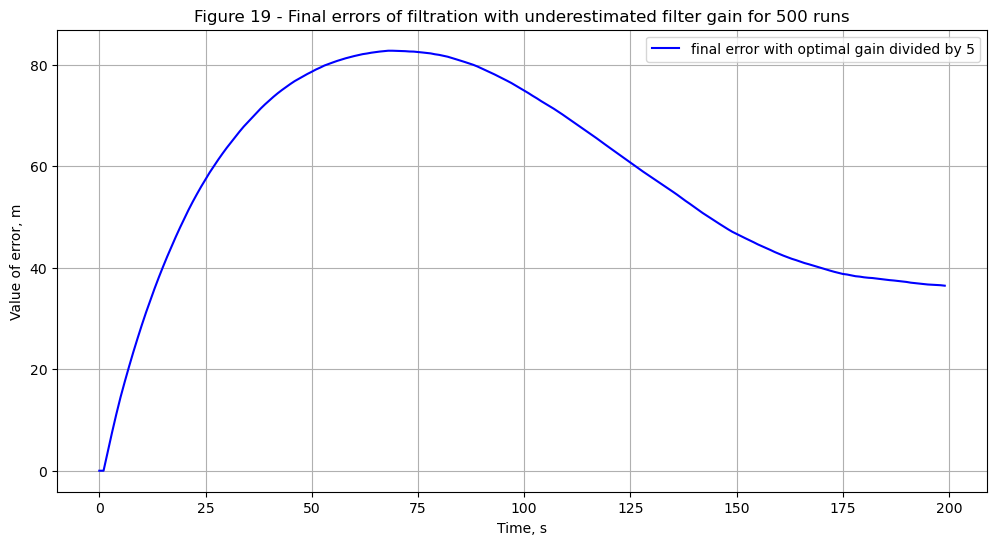

In [39]:
#Plot of the final error with underestimated P
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue",  label='final error with optimal gain divided by 5')
plt.title('Figure 19 - Final errors of filtration with underestimated filter gain for 500 runs')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

As we can see from the comparison, when the coefficient is too low, the error increases significantly and becomes very unstable. Therefore, the Kalman filter's settings greatly affect its performance.

**Conclusion:**

The Kalman filter successfully filters measurements and provides estimates close to the actual trajectory, however, filtering errors cannot be completely eliminated due to uncertainty. The initial values of the initial filtration error covariance matrix and the initial estimate of state vector affect only the initial stage of the filter operation. When the filter reaches steady-state mode, the initial conditions cease to significantly affect the accuracy of estimates.
When trying to predict the state 6 steps ahead, the final error of filtration increased, as uncertainty increased

Applying a deterministic motion model when the actual motion is subject to random accelerations has shown that ignoring the covariance matrix of state noise leads to the fact that the state error of the Kalman filter does not correspond to the actual divergence error.

We also found out that the gain of the filter depends on the ratio of the variances of the state noise and measurements, the higher the ratio, the greater the gain. The filter has to rely more on measurements due to the higher uncertainty of the motion model.

We also learned that if we greatly reduce the optimal filter gain, the error increases significantly and becomes very unstable. Therefore, the Kalman filter's settings greatly affect its performance.

Thus, as a result of the lab work, we repeatedly confirmed the performance of the Kalman filter. It thus performs better than an exponential filter or a running mean filter. However, its application complexity is significantly higher. Each tuning parameter plays a significant role in its performance. We repeatedly confirmed the importance of fine-tuning the Kalman filter, for example, by changing the gain.

**Learning log:**

What we learned:

We learned that the Kalman filter provides an estimate not only based on the measurements obtained, but also based on the model. Also, the Kalman filter is able to distinguish the model's own noise from measurement noise, meaning we can filter measurement noise without filtering the model's own noise.

We explored how to apply the Kalman filter, how its settings affect its performance, and how each parameter should be configured. We also realized in practice how important it is to fine-tune the filter.

We realized that the filter gain is not a constant, but a variable that also varies depending on the uncertainty of the model and the uncertainty of measurements.

What difficulties we faced:

We encountered a problem understanding the filter's operation from a mathematical perspective. We also had difficulty understanding the influence of the coefficients.

It was difficult to understand if the filter was working good by looking at a single run.